### **Importing packages**

In [112]:
import numpy as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE,BorderlineSMOTE,ADASYN,SVMSMOTE,KMeansSMOTE,SMOTEN
from imblearn.combine import SMOTEENN,SMOTETomek
from imblearn.under_sampling import AllKNN,RandomUnderSampler,ClusterCentroids
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report,RocCurveDisplay,roc_auc_score,ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier,RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from scipy.stats import randint, uniform, loguniform
from sklearn.metrics import precision_recall_curve
from imblearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold,StratifiedShuffleSplit

### **Reading and exploring the data**

In [113]:
df=pd.read_csv('creditcard.csv')

In [114]:
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [115]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

**Missing values check**

In [117]:
df.isna().sum().sum()

np.int64(0)

**Duplicated rows check**

In [118]:
df.duplicated().sum()

np.int64(1081)

In [119]:
df.drop_duplicates(inplace=True)

**Correlation heamap and features correlation with the target**

<Axes: >

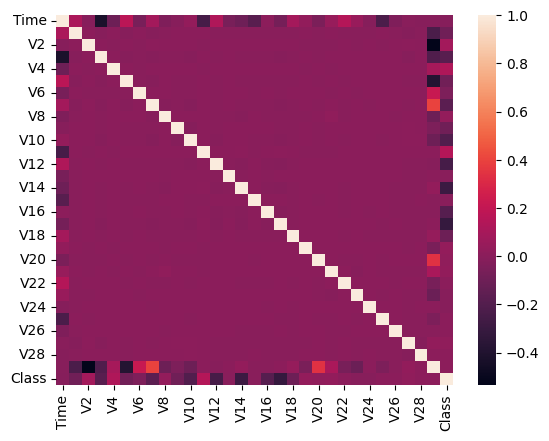

In [120]:
sns.heatmap(df.corr())

In [121]:
df.corr()['Class'].sort_values(ascending=True)

V17      -0.313498
V14      -0.293375
V12      -0.250711
V10      -0.206971
V16      -0.187186
V3       -0.182322
V7       -0.172347
V18      -0.105340
V1       -0.094486
V9       -0.094021
V5       -0.087812
V6       -0.043915
Time     -0.012359
V24      -0.007210
V23      -0.006333
V13      -0.003897
V15      -0.003300
V25       0.003202
V26       0.004265
V22       0.004887
Amount    0.005777
V28       0.009682
V20       0.021486
V27       0.021892
V21       0.026357
V8        0.033068
V19       0.033631
V2        0.084624
V4        0.129326
V11       0.149067
Class     1.000000
Name: Class, dtype: float64

**The target label is %0.166 of the cases which means we r dealing with highly unbalanced dataset**

In [122]:
print(df['Class'].value_counts())
print('\n==============================')
df['Class'].value_counts()[1]/(len(df)) *100

Class
0    283253
1       473
Name: count, dtype: int64



np.float64(0.1667101358352777)

**Visualizing features columns with the target**

In [123]:
cols=df.drop('Class',axis=1).columns.tolist()

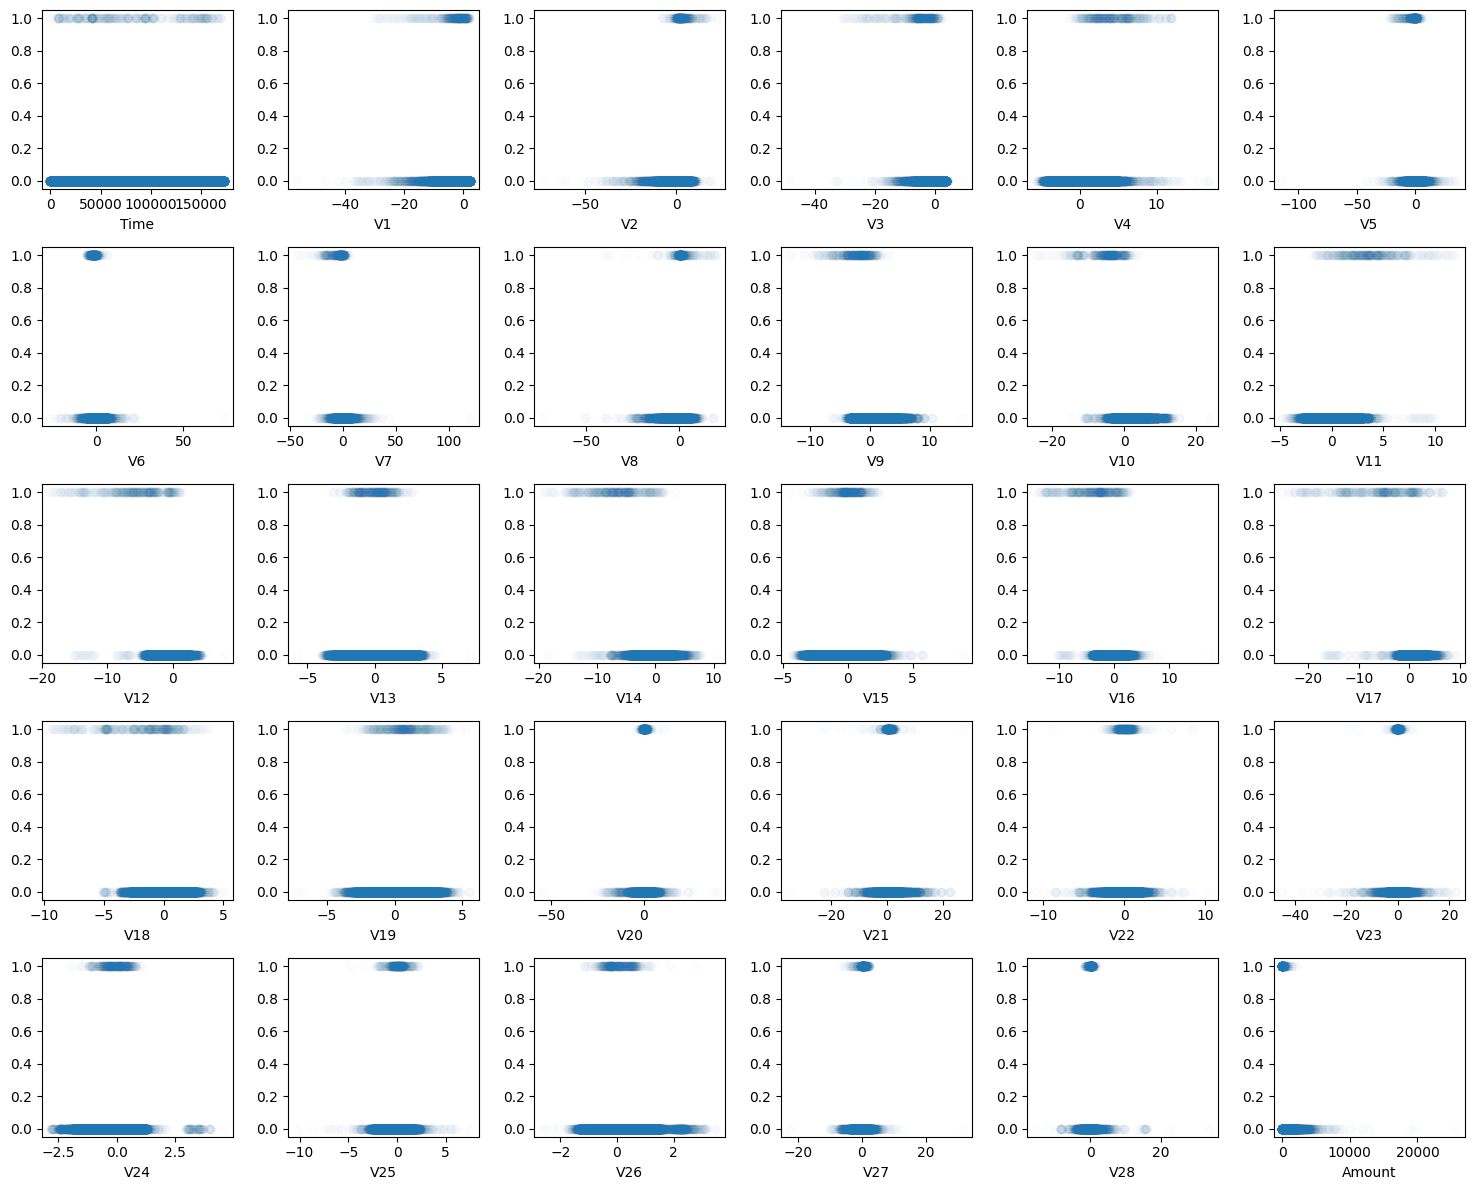

In [124]:
fig, ax=plt.subplots(5,6)
fig.set_figwidth(15)
fig.set_figheight(12)
ax=ax.flatten()
for i, col in enumerate(cols):
    ax[i].scatter(x=df[col], y=df['Class'],alpha=0.01)
    ax[i].set_xlabel(f'{col}')
plt.tight_layout()

**Visulaizing the distripution of features**

**we can see that the amount column is positively skewed, and the time columns needs to be standarized to eliminate any scaling issues so these columns need some work before they become model-ready**

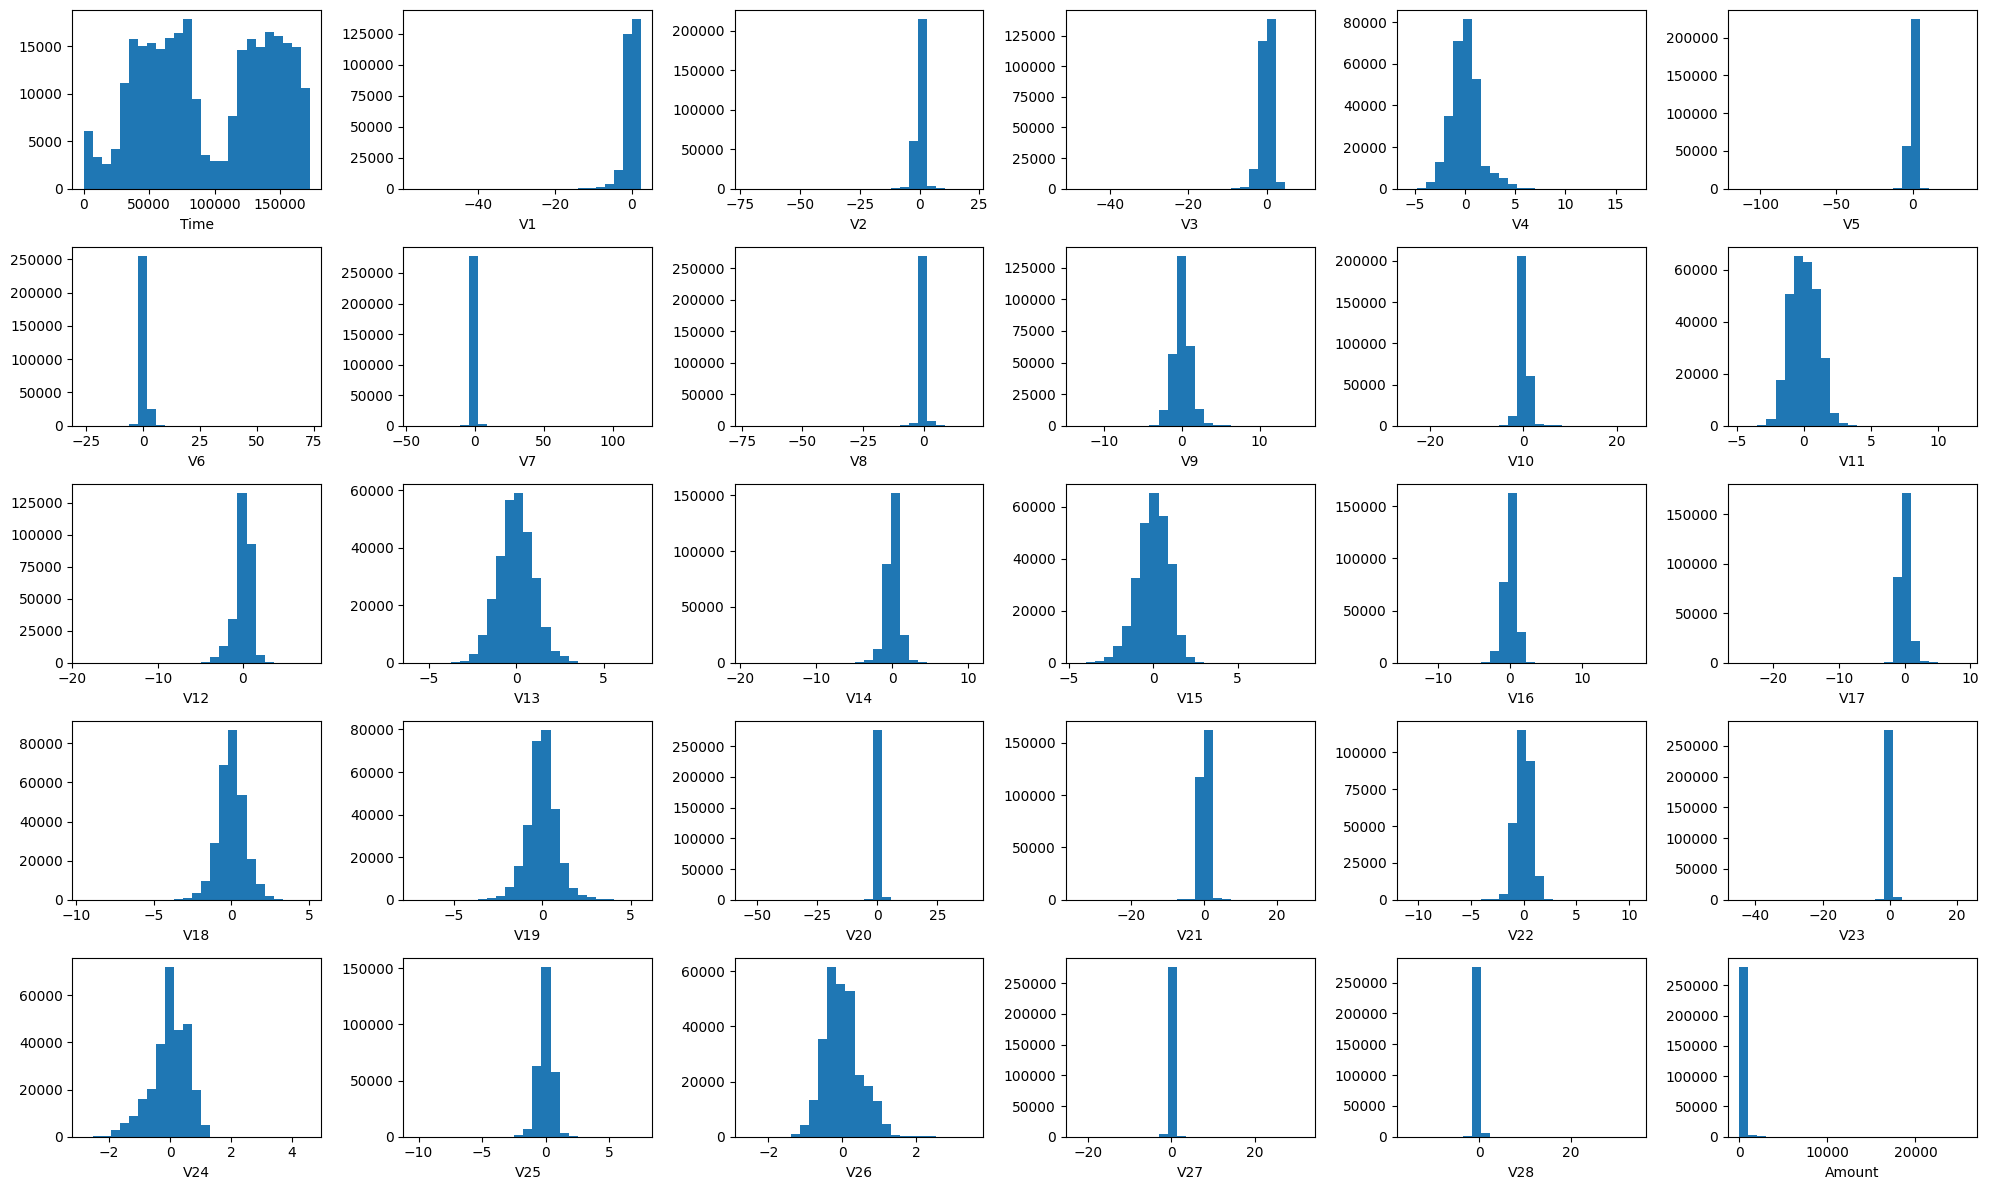

In [125]:
fig, ax=plt.subplots(5,6)
fig.set_figwidth(20)
fig.set_figheight(12)
ax=ax.flatten()
for i, col in enumerate(cols):
    ax[i].hist(df[col],bins=25)
    ax[i].set_xlabel(f'{col}')
plt.tight_layout()

### **Feature engineering**

**Applying log transformaation to the time and amount columns**

In [126]:
df['Time']=np.log1p(df['Time']+1) # we adding 1 here to eliminate the issues that may arrise from time having values of zero,it wont change the overall relative distripution of the time column

In [127]:
df['Amount']=np.log1p(df['Amount'])

**Extracting new column that describes the amount of a transaction per unit time**

In [128]:
df['amount_per_unit_time']=df['Amount']/((df['Time']))

<Axes: >

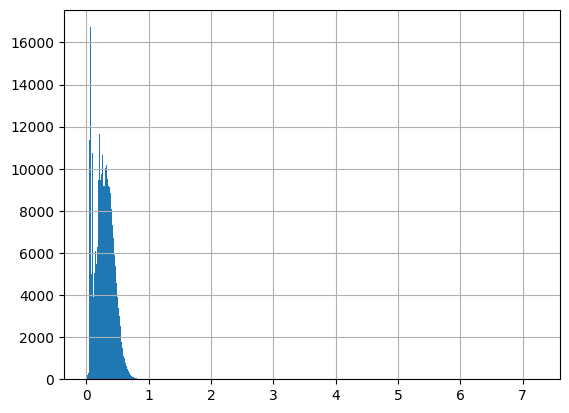

In [129]:
df['amount_per_unit_time'].hist(bins=500)

In [130]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,amount_per_unit_time
0,0.693147,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,5.014760,0,7.234770
1,0.693147,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,1.305626,0,1.883621
2,1.098612,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,5.939276,0,5.406162
3,1.098612,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,4.824306,0,4.391272
4,1.386294,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,4.262539,0,3.074772
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,12.059821,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.570980,0,0.047346
284803,12.059826,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,3.249987,0,0.269489
284804,12.059832,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,4.232366,0,0.350947
284805,12.059832,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,2.397895,0,0.198833


**We can see now that the amount column is more confined**

<Axes: >

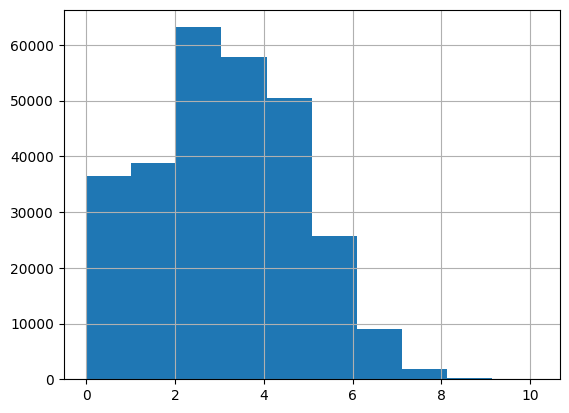

In [131]:
df['Amount'].hist()

**extracting rolling mean for the prior 10 values of the amount column, since fraud cases usually deviate from the normal transaction values so a rolling mean might help the model catch those sneaky fraud cases**

In [132]:
df['10_rolls_amount_mean']=df['Amount'].rolling(window=10,min_periods=1).mean()

In [133]:
df['10_rolls_amount_mean']

0         5.014760
1         3.160193
2         4.086554
3         4.270992
4         4.269301
            ...   
284802    2.158853
284803    2.304843
284804    2.664421
284805    2.665610
284806    2.792972
Name: 10_rolls_amount_mean, Length: 283726, dtype: float64

In [134]:
df1=df.drop('Class',axis=1)
df1

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,amount_per_unit_time,10_rolls_amount_mean
0,0.693147,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,5.014760,7.234770,5.014760
1,0.693147,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,1.305626,1.883621,3.160193
2,1.098612,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,5.939276,5.406162,4.086554
3,1.098612,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,4.824306,4.391272,4.270992
4,1.386294,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,4.262539,3.074772,4.269301
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,12.059821,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.570980,0.047346,2.158853
284803,12.059826,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,3.249987,0.269489,2.304843
284804,12.059832,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,4.232366,0.350947,2.664421
284805,12.059832,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,2.397895,0.198833,2.665610


In [135]:
df1.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,amount_per_unit_time,10_rolls_amount_mean
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,11.252632,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,3.153760,0.282351,3.153775
std,0.817146,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,1.657080,0.152683,0.595375
min,0.693147,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000,0.009950
25%,10.900561,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,1.887070,0.168318,2.775412
50%,11.346806,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,3.135494,0.280099,3.163800
75%,11.844385,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,4.363226,0.388765,3.552961
max,12.059855,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,10.153941,7.234770,5.453301


**clustering the PCA transfromed columns since its hard to extract any useful information from them alone**

In [136]:
cluster=KMeans(n_clusters=10,random_state=42)


In [137]:
scaler=RobustScaler()
df1=scaler.fit_transform(df1)


In [138]:
pd.DataFrame(df1)

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,-11.287755,-0.618360,-0.097622,1.229434,0.880878,-0.218773,0.632648,0.176974,0.143677,0.335739,...,0.253199,-0.320939,0.032627,0.168017,-0.241512,0.816068,-0.246698,0.758945,31.548030,2.380506
1,-11.287755,0.524849,0.144367,-0.007034,0.295891,0.087159,0.165383,-0.106558,0.118241,-0.163546,...,-0.602596,0.363373,-0.479559,0.225835,0.314036,-0.064639,0.026214,-0.738995,7.273954,-0.004639
2,-10.858157,-0.617709,-1.002505,0.831270,0.252882,-0.345402,1.780431,0.668400,0.422384,-1.178892,...,0.714327,2.974843,-0.919547,-0.514733,-0.153300,-0.351138,-0.541896,1.132312,23.253034,1.186747
3,-10.858157,-0.442046,-0.177906,0.841592,-0.529031,0.033147,1.305834,0.175202,0.665139,-1.075980,...,-0.001308,-0.578965,-1.531860,0.944541,-0.299382,0.378404,0.382702,0.682029,18.649254,1.423951
4,-10.553352,-0.528050,0.581026,0.714142,0.267510,-0.271669,0.318307,0.491620,-0.547078,0.701771,...,0.739164,-0.408139,0.126231,-0.332690,0.977848,1.346586,1.555108,0.455159,12.677297,1.421777
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283721,0.755453,-5.332169,7.145374,-5.225152,-1.285968,-4.078964,-2.000020,-4.415983,13.625815,1.586057,...,0.098221,3.314371,-0.692986,2.126054,0.532968,5.821307,6.197405,-1.035684,-1.055825,-1.292456
283722,0.755459,-0.337440,-0.084985,0.967874,-0.450591,0.707883,1.143898,-0.014720,0.510672,0.513947,...,0.856915,0.076334,-1.331217,-0.932275,-0.605059,0.413928,-0.494416,0.046238,-0.048131,-1.104699
283723,0.755465,0.850880,-0.260747,-1.789381,-0.336889,2.061355,2.836132,-0.300704,1.284337,0.391107,...,0.533691,-0.085126,0.754375,0.373368,-0.062077,0.018389,-0.288712,0.442973,0.321384,-0.642248
283724,0.755465,-0.116856,0.333095,0.272637,0.447890,-0.249218,0.771022,-0.647418,1.229575,0.358558,...,0.740817,-0.491641,0.103488,-0.876203,1.056109,0.663224,0.711284,-0.297881,-0.368641,-0.640719


In [139]:
cluster.fit(df1)

,n_clusters,10
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [140]:
cluster.inertia_

10105503.789189536

**Creating new feature called clusterd that refers to the cluster which the data point belongs to**

In [141]:
df['clusterd']=cluster.labels_

In [142]:
df['clusterd'][df['Class']==1].value_counts()

clusterd
9    214
1     75
7     74
8     54
2     21
6     17
0     11
5      7
Name: count, dtype: int64

In [143]:
df[df['Class']==1]['clusterd'].value_counts()

clusterd
9    214
1     75
7     74
8     54
2     21
6     17
0     11
5      7
Name: count, dtype: int64

### **Model selection**

**Defining a function that takes the data frame and splits it into training and testing sets , then it applis the robust scaling method then it trains the model and evaluates it giving its classification report and ploting its confusion matrix**

In [144]:
def sampling_sweep(sampler,classifier,df):
    x=df.drop('Class',axis=1)
    y=df['Class']
    x_train,x_test, y_train, y_test =train_test_split(x,y, test_size=0.3, random_state=42,stratify=y,shuffle=True)
    scaler=RobustScaler()
    x_train=scaler.fit_transform(x_train)
    x_train,y_train=sampler.fit_resample(x_train,y_train)
    classifier.fit(x_train,y_train)
    print(f'{sampler,classifier} results:')
    print(classification_report(y_test,classifier.predict(x_test)))
    print('===============================\n')
    RocCurveDisplay.from_estimator(classifier,x_test,y_test)
    

**Oversampling**

**Looping over diffrent over samlping techniques**

In [145]:
samplers=[SMOTE(), BorderlineSMOTE(), ADASYN(), SMOTEN(),SMOTEENN(),SMOTETomek(),KMeansSMOTE(cluster_balance_threshold=0.0025)]

**Using LightGBM as the base classifier becuase it's super fast**

(SMOTE(), LGBMClassifier(n_jobs=-1, verbosity=-1)) results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     84976
           1       0.61      0.75      0.67       142

    accuracy                           1.00     85118
   macro avg       0.80      0.87      0.83     85118
weighted avg       1.00      1.00      1.00     85118


(BorderlineSMOTE(), LGBMClassifier(n_jobs=-1, verbosity=-1)) results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     84976
           1       0.80      0.77      0.79       142

    accuracy                           1.00     85118
   macro avg       0.90      0.89      0.89     85118
weighted avg       1.00      1.00      1.00     85118


(ADASYN(), LGBMClassifier(n_jobs=-1, verbosity=-1)) results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     84976
           1       0.76      0.77      0.77 

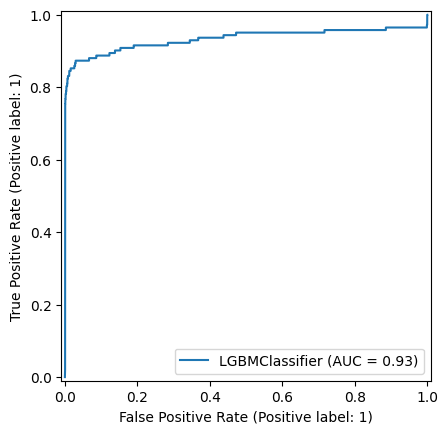

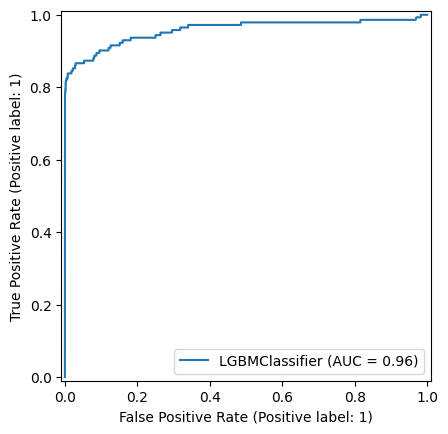

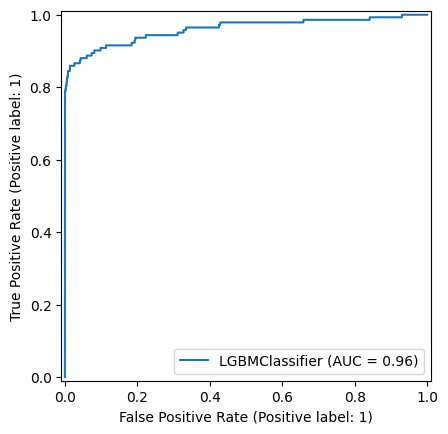

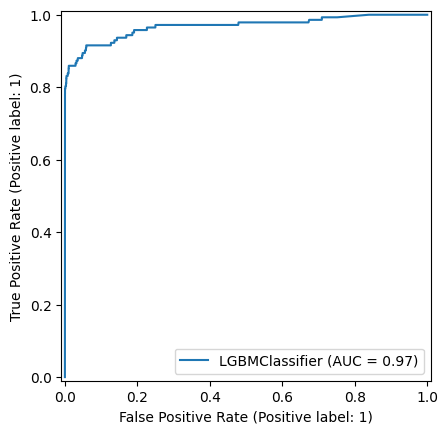

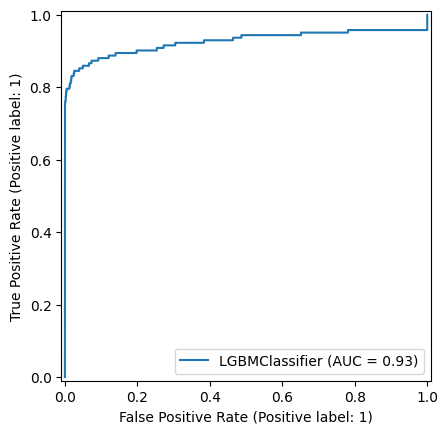

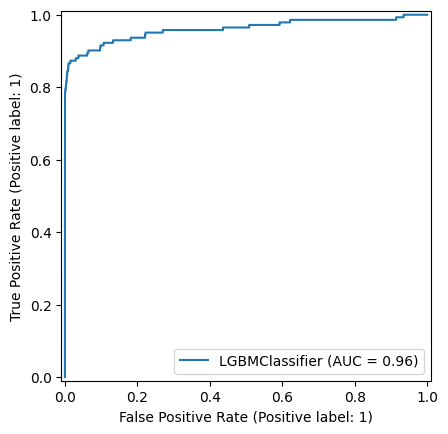

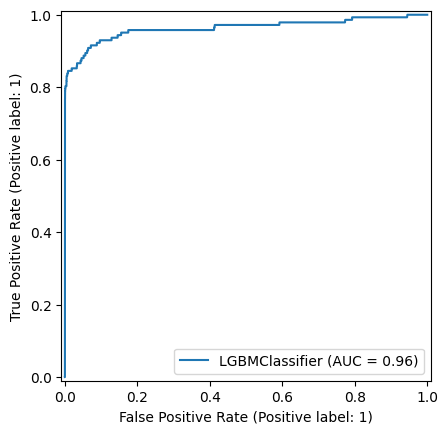

In [146]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
for sampler in samplers:
    sampling_sweep(sampler=sampler,classifier=LGBMClassifier(verbosity=-1,n_jobs=-1),df=df)

**SMOTEN gives the best results**

**looping over under sampling techniques**

(AllKNN(), LGBMClassifier(n_jobs=-1, verbosity=-1)) results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     84976
           1       0.21      0.55      0.30       142

    accuracy                           1.00     85118
   macro avg       0.60      0.77      0.65     85118
weighted avg       1.00      1.00      1.00     85118


(RandomUnderSampler(), LGBMClassifier(n_jobs=-1, verbosity=-1)) results:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     84976
           1       0.04      0.89      0.08       142

    accuracy                           0.96     85118
   macro avg       0.52      0.93      0.53     85118
weighted avg       1.00      0.96      0.98     85118


(ClusterCentroids(), LGBMClassifier(n_jobs=-1, verbosity=-1)) results:
              precision    recall  f1-score   support

           0       1.00      0.87      0.93     84976
           1       0.01      0

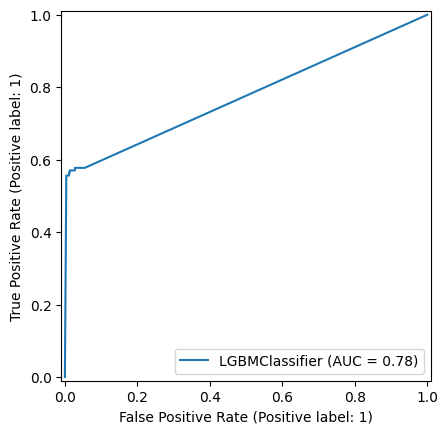

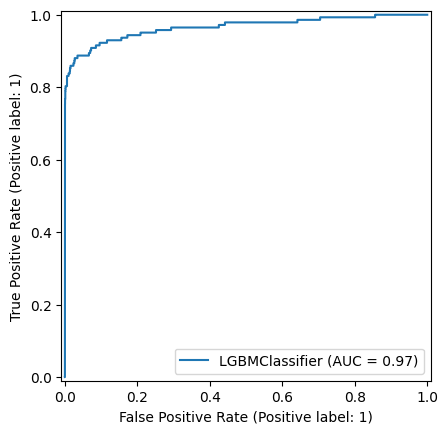

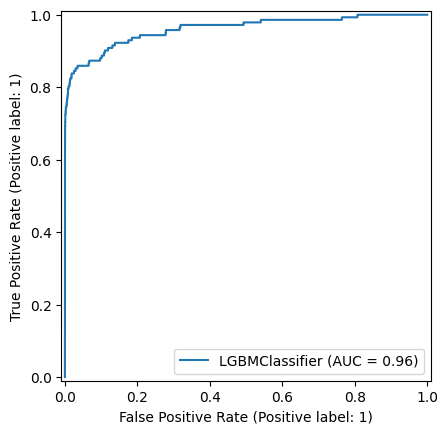

In [147]:

for sampler in [AllKNN(),RandomUnderSampler(),ClusterCentroids()]:
    sampling_sweep(sampler=sampler,classifier=LGBMClassifier(verbosity=-1,n_jobs=-1),df=df)

**We see that over sampling in this data set is better than under sampling so we will stick to SMOTEN**

**Looping over diffrent classifiers while unifing the over sampling method to best choose the appropriate classiffier**

(SMOTEN(random_state=42, sampling_strategy='minority'), LogisticRegression(n_jobs=-1)) results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     84976
           1       0.79      0.34      0.47       142

    accuracy                           1.00     85118
   macro avg       0.89      0.67      0.74     85118
weighted avg       1.00      1.00      1.00     85118


(SMOTEN(random_state=42, sampling_strategy='minority'), DecisionTreeClassifier()) results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     84976
           1       0.49      0.69      0.57       142

    accuracy                           1.00     85118
   macro avg       0.74      0.84      0.79     85118
weighted avg       1.00      1.00      1.00     85118


(SMOTEN(random_state=42, sampling_strategy='minority'), AdaBoostClassifier()) results:
              precision    recall  f1-score   support

           0   

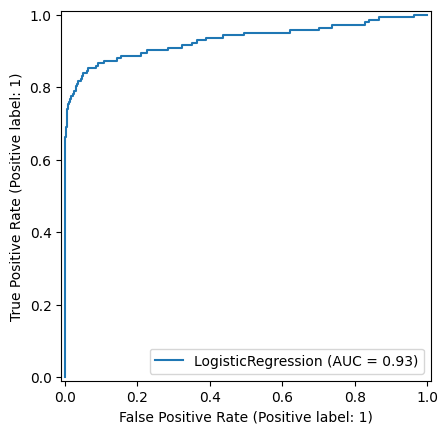

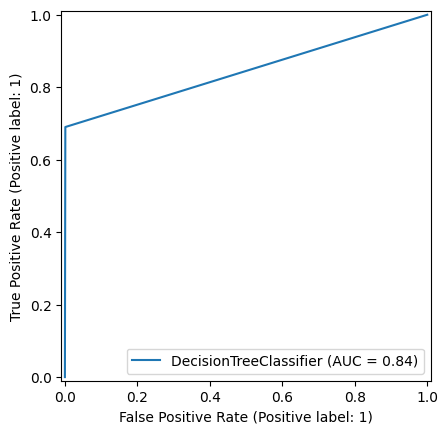

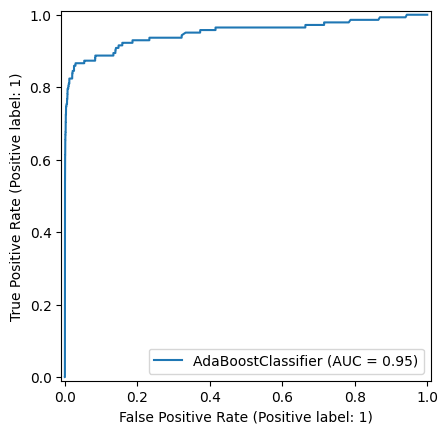

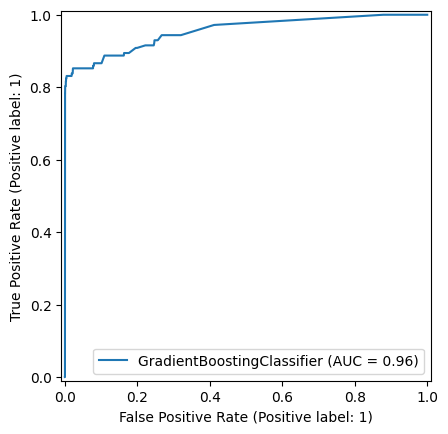

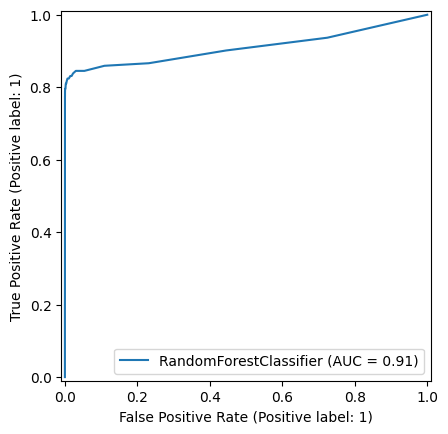

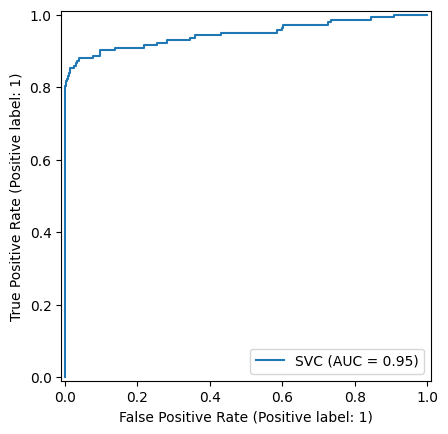

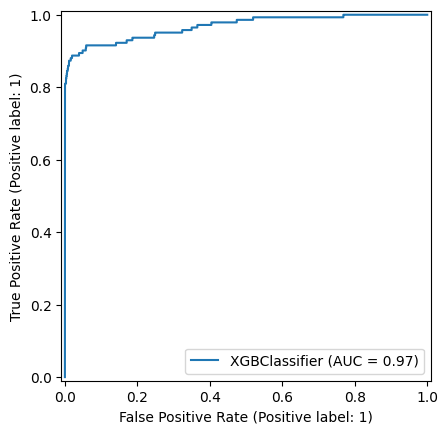

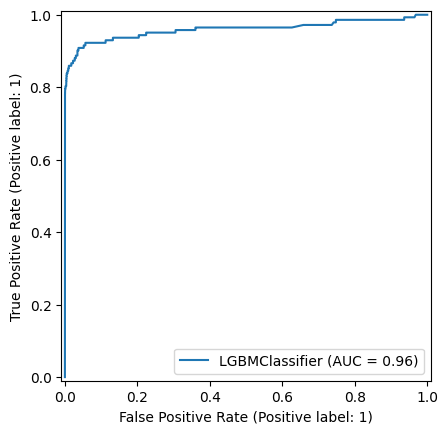

In [148]:
for classifier in [LogisticRegression(verbose=0,n_jobs=-1),DecisionTreeClassifier(),AdaBoostClassifier(),GradientBoostingClassifier(verbose=0,),RandomForestClassifier(verbose=0,n_jobs=-1),SVC(verbose=0),XGBClassifier(verbosity=0,n_jobs=-1),LGBMClassifier(verbosity=-1,n_jobs=-1)]:
    sampling_sweep(sampler=SMOTEN(random_state=42,sampling_strategy='minority'),classifier=classifier,df=df)

**Both random forest and XGboost give great results but we will choose XGboost due to the large dataset and tuning xgboost will be easier and computationally faster**

**Defining parameters distripution**

In [155]:
xgb_param_dist = {
    'xgb__n_estimators': randint(200, 1000),
    'xgb__learning_rate': uniform(0.01, 0.3),
    'xgb__max_depth': randint(3, 12),
    'xgb__subsample': uniform(0.5, 0.5),
    'xgb__colsample_bytree': uniform(0.5, 0.5),
    'xgb__gamma': uniform(0, 5),
    'xgb__reg_alpha': uniform(0, 5),
    'xgb__reg_lambda': uniform(0, 5),
    'xgb__scale_pos_weight': [1, 10, 25, 50, 100]}

**Using RandomSearchCV to tune the hyberparameters for XGBoost algorithm givin the wide range of parameters avaliable to tune as seen in xgb_param_dist**

**We use stratified kfold to make sure that each fold of the cross validation is homegenous in its target value counts so we dont get lucky and unlucky folds when cross validating**

**Usually we split the data into train,evaluation and test sets but since we r using random search which has internal cross validation we dont need to split further than a standard train test split and the cross validation inside the random search will further split the training data into subsets for training and others for evaluation on its own using the stratified k fold method we provided**

In [154]:
pl=Pipeline([('sampling',SMOTEN(sampling_strategy='minority',random_state=42)),('xgb',XGBClassifier())])

Model expected performance on training data:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    198277
           1       0.99      1.00      0.99       331

    accuracy                           1.00    198608
   macro avg       0.99      1.00      1.00    198608
weighted avg       1.00      1.00      1.00    198608



Model expected performance on unseen data:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     84976
           1       0.93      0.77      0.85       142

    accuracy                           1.00     85118
   macro avg       0.97      0.89      0.92     85118
weighted avg       1.00      1.00      1.00     85118





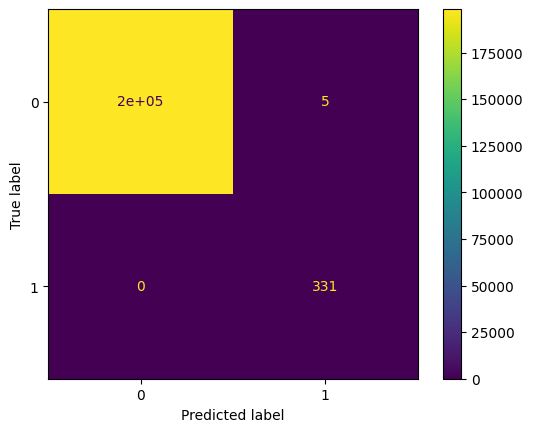

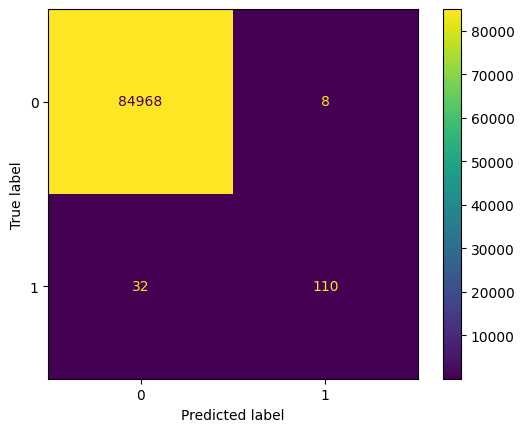

In [ ]:
x=df.drop('Class',axis=1)
y=df['Class']
x_train,x_test, y_train, y_test =train_test_split(x,y, test_size=0.3, random_state=42,stratify=y,shuffle=True)
scaler=RobustScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)
kfcv=StratifiedKFold(n_splits=10,shuffle=True,random_state=42)
mdl=RandomizedSearchCV(estimator=pl,param_distributions=xgb_param_dist,cv=kfcv,n_jobs=-1,scoring='f1_macro',random_state=42)
mdl.fit(x_train,y_train)
print('Model performance on training data:')
ConfusionMatrixDisplay.from_predictions(y_train,mdl.predict(x_train))
print(classification_report(y_train,mdl.predict(x_train)))
print('\n=============================================\n')
print('Model expected performance on unseen data:')
ConfusionMatrixDisplay.from_predictions(y_test,mdl.predict(x_test))
print(classification_report(y_test,mdl.predict(x_test)))
print('\n=============================================\n')

### **Final remarks**

**So here are our final results, The model hits macro F1-score of 0.92 on unseen data, indicating strong generalization and good performance on imbalanced data, and The drop from training to testing data results is realistic, not suspiciously small or large**

**We are achieving a good balance between precision and recall, which is good is such an imbalanced dataset**

**And here end our brief journey with this dataset , i learned so much about imbalanced datasets from doing this project and it has been actually very fun to work on, so ... see ya**